# Assignment 01

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.losses import binary_crossentropy
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


## Dataset


In [19]:
import kagglehub

# Download latest version
kaggle_path = kagglehub.dataset_download("andrewmvd/medical-mnist")

print("Path to dataset files:", kaggle_path)

Using Colab cache for faster access to the 'medical-mnist' dataset.
Path to dataset files: /kaggle/input/medical-mnist


In [20]:
regions = sorted([
    folder for folder in os.listdir(kaggle_path)
    if os.path.isdir(os.path.join(kaggle_path, folder))
])

print("Regions:", regions)


Regions: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']


## Params

In [34]:
# @title
IMG_SIZE = 64 # @param {"type":"number"}
BATCH_SIZE = 64 # @param {"type":"number"}
LATENT_DIM = 16 # @param {"type":"number"}
EPOCHS = 5 # @param {"type":"number"}

In [23]:
def load_region_dataset(region):

    path = os.path.join(kaggle_path, region)

    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        labels=None,
        color_mode="grayscale",
        batch_size=BATCH_SIZE,
        image_size=(IMG_SIZE, IMG_SIZE),
        shuffle=True
    )

    # normalize
    ds = ds.map(lambda x: x / 255.0)

    # for Autoencoder target = input
    ds = ds.map(lambda x: (x, x))

    return ds

## Models

### AutoEncoder

In [ ]:
def build_autoencoder():

    inputs = layers.Input(shape=(IMG_SIZE,IMG_SIZE,1))

    x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    latent = layers.Dense(LATENT_DIM)(x)

    x = layers.Dense(16*16*64, activation='relu')(latent)
    x = layers.Reshape((16,16,64))(x)

    x = layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(x)
    x = layers.Conv2DTranspose(32,3,strides=2,padding='same',activation='relu')(x)

    outputs = layers.Conv2D(1,3,padding='same',activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')

    return model


### VAE

In [32]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def build_vae():

    # Encoder
    encoder_inputs = layers.Input(shape=(IMG_SIZE,IMG_SIZE,1))

    x = layers.Conv2D(32,3,activation='relu',padding='same')(encoder_inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)

    z_mean = layers.Dense(LATENT_DIM)(x)
    z_log_var = layers.Dense(LATENT_DIM)(x)

    z = Sampling()([z_mean, z_log_var])

    encoder = Model(encoder_inputs, [z_mean, z_log_var, z])

    # Decoder
    latent_inputs = layers.Input(shape=(LATENT_DIM,))
    x = layers.Dense(16*16*64, activation='relu')(latent_inputs)
    x = layers.Reshape((16,16,64))(x)

    x = layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(x)
    x = layers.Conv2DTranspose(32,3,strides=2,padding='same',activation='relu')(x)

    decoder_outputs = layers.Conv2D(1,3,padding='same',activation='sigmoid')(x)

    decoder = Model(latent_inputs, decoder_outputs)

    # VAE
    class VAE(Model):
        def __init__(self, encoder, decoder):
            super().__init__()
            self.encoder = encoder
            self.decoder = decoder

        def train_step(self, data):
            if isinstance(data, tuple):
                data = data[0]
            with tf.GradientTape() as tape:

                z_mean, z_log_var, z = self.encoder(data)
                reconstruction = self.decoder(z)

                recon_loss = tf.reduce_mean(
                    tf.reduce_sum(
                        binary_crossentropy(data, reconstruction),
                        axis=(1,2)
                    )
                )

                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(
                        1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                        axis=1
                    )
                )

                total_loss = recon_loss + kl_loss

            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

            return {
                "loss": total_loss,
                "recon_loss": recon_loss,
                "kl_loss": kl_loss
            }

    vae = VAE(encoder, decoder)
    vae.compile(optimizer='adam')

    return vae, encoder, decoder

## Visualization

In [25]:
def show_reconstruction(model, dataset, title):

    batch = next(iter(dataset.take(1)))

    # if dataset gives (x,y)
    if isinstance(batch, tuple):
        sample = batch[0]
    else:
        sample = batch

    sample = sample[:5]

    recon = model.predict(sample, verbose=0)

    plt.figure(figsize=(12,4))

    for i in range(5):

        plt.subplot(2,5,i+1)
        plt.imshow(sample[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")

        plt.subplot(2,5,i+6)
        plt.imshow(recon[i].squeeze(), cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

## Training

In [35]:
results = {region: {"ae":False, "vae":False} for region in regions}
results

{'AbdomenCT': {'ae': False, 'vae': False},
 'BreastMRI': {'ae': False, 'vae': False},
 'CXR': {'ae': False, 'vae': False},
 'ChestCT': {'ae': False, 'vae': False},
 'Hand': {'ae': False, 'vae': False},
 'HeadCT': {'ae': False, 'vae': False}}

In [43]:
results

{'AbdomenCT': {'ae': True, 'vae': False},
 'BreastMRI': {'ae': False, 'vae': False},
 'CXR': {'ae': False, 'vae': False},
 'ChestCT': {'ae': False, 'vae': False},
 'Hand': {'ae': False, 'vae': False},
 'HeadCT': {'ae': False, 'vae': False}}

Training Region: AbdomenCT
Found 10000 files.
=============== Variational AutoEncoder ===============
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 159s 991ms/step - kl_loss: 0.0337 - loss: 2793.0225 - recon_loss: 2792.9888
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 156s 994ms/step - kl_loss: 2.8166 - loss: 2790.2966 - recon_loss: 2787.4800
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 157s 997ms/step - kl_loss: 3.0983 - loss: 2778.0981 - recon_loss: 2775.0000
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 157s 999ms/step - kl_loss: 8.4255 - loss: 2758.6838 - recon_loss: 2750.2583
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 157s 999ms/step - kl_loss: 8.6784 - loss: 2756.0320 - recon_loss: 2747.3535


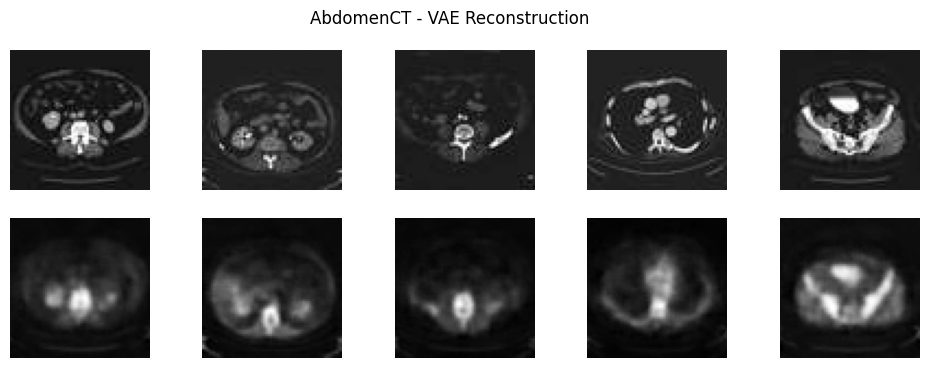

Training Region: BreastMRI
Found 8954 files.
=============== AutoEncoder ===============
Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 142s 994ms/step - loss: 0.0497
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - loss: 0.0218
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 139s 991ms/step - loss: 0.0123
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 139s 995ms/step - loss: 0.0085
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 140s 998ms/step - loss: 0.0069


<Figure size 640x480 with 0 Axes>

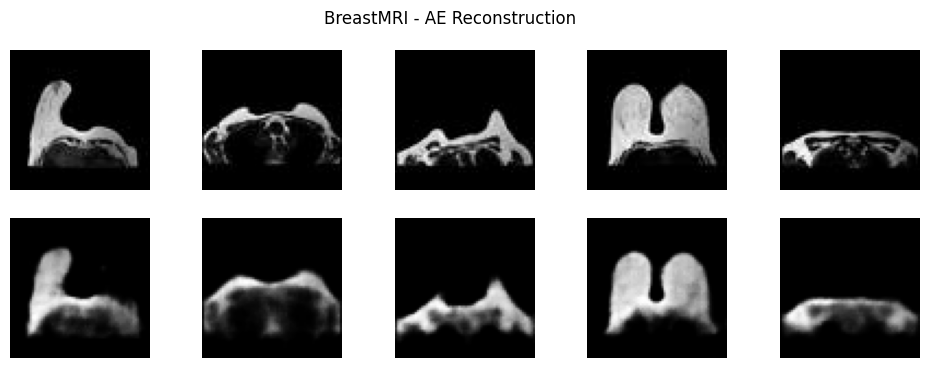

=============== Variational AutoEncoder ===============
Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - kl_loss: 19.5258 - loss: 864.0292 - recon_loss: 844.5034
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 140s 1000ms/step - kl_loss: 21.4778 - loss: 819.5891 - recon_loss: 798.1112
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - kl_loss: 24.1853 - loss: 785.5102 - recon_loss: 761.3249
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - kl_loss: 25.0800 - loss: 750.4989 - recon_loss: 725.4189
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - kl_loss: 26.2525 - loss: 775.7883 - recon_loss: 749.5357


<Figure size 640x480 with 0 Axes>

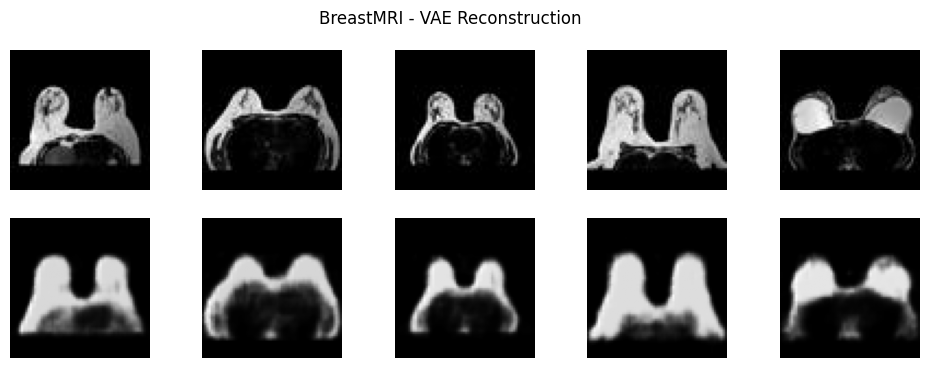

Training Region: CXR
Found 10000 files.
=============== AutoEncoder ===============
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - loss: 0.0409
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - loss: 0.0143
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - loss: 0.0105
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - loss: 0.0092
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - loss: 0.0086


<Figure size 640x480 with 0 Axes>

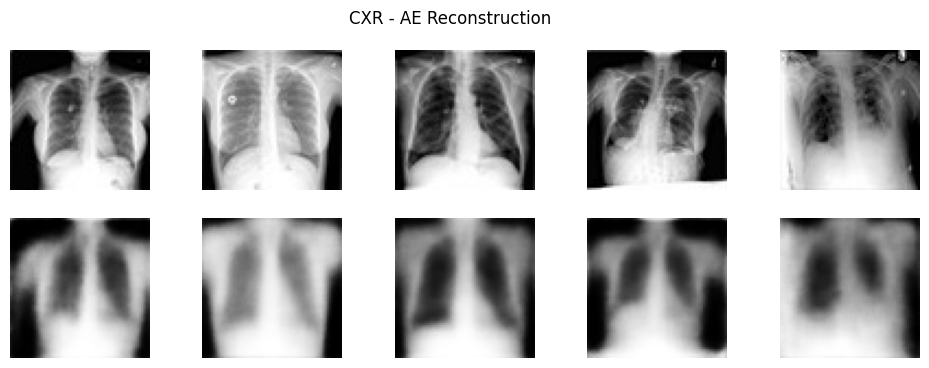

=============== Variational AutoEncoder ===============
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - kl_loss: 18.0322 - loss: 2364.2593 - recon_loss: 2346.2271
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - kl_loss: 27.8017 - loss: 2105.9497 - recon_loss: 2078.1479
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - kl_loss: 30.3717 - loss: 2057.0476 - recon_loss: 2026.6758
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - kl_loss: 31.1029 - loss: 1933.7911 - recon_loss: 1902.6882
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - kl_loss: 30.9334 - loss: 2086.1399 - recon_loss: 2055.2065


<Figure size 640x480 with 0 Axes>

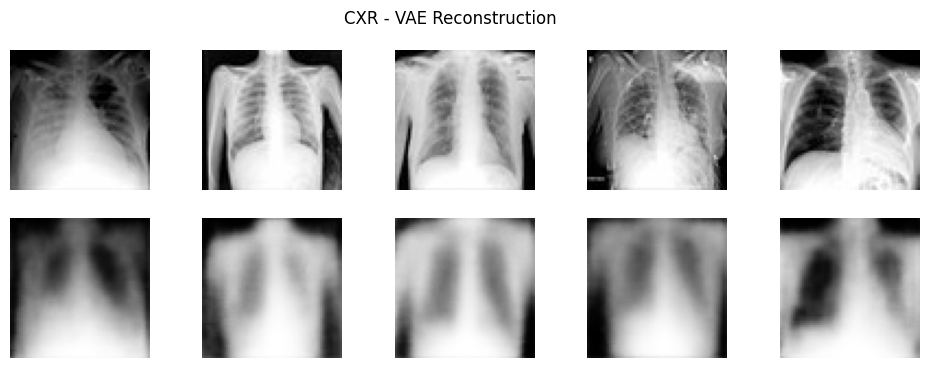

Training Region: ChestCT
Found 10000 files.
=============== AutoEncoder ===============
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - loss: 0.0033
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - loss: 0.0029
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - loss: 0.0027
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - loss: 0.0025
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - loss: 0.0024


<Figure size 640x480 with 0 Axes>

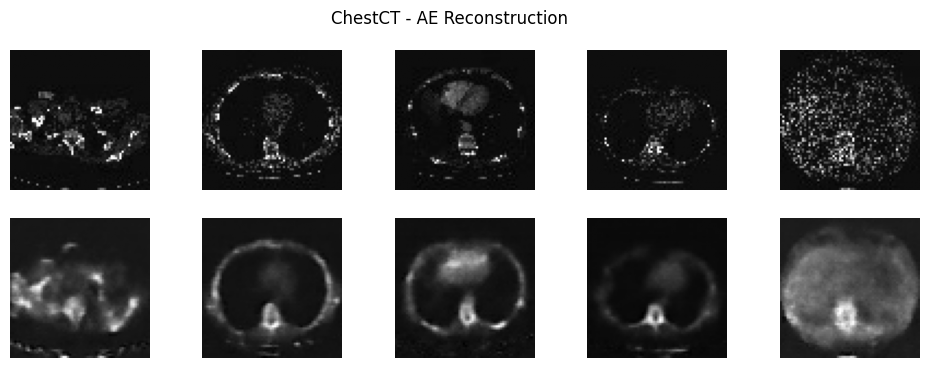

=============== Variational AutoEncoder ===============
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - kl_loss: 0.0487 - loss: 2835.2290 - recon_loss: 2835.1804
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - kl_loss: 0.1929 - loss: 2833.5256 - recon_loss: 2833.3328
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - kl_loss: 0.2804 - loss: 2835.5969 - recon_loss: 2835.3167
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - kl_loss: 0.3106 - loss: 2833.8208 - recon_loss: 2833.5103
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - kl_loss: 0.3828 - loss: 2835.3899 - recon_loss: 2835.0071


<Figure size 640x480 with 0 Axes>

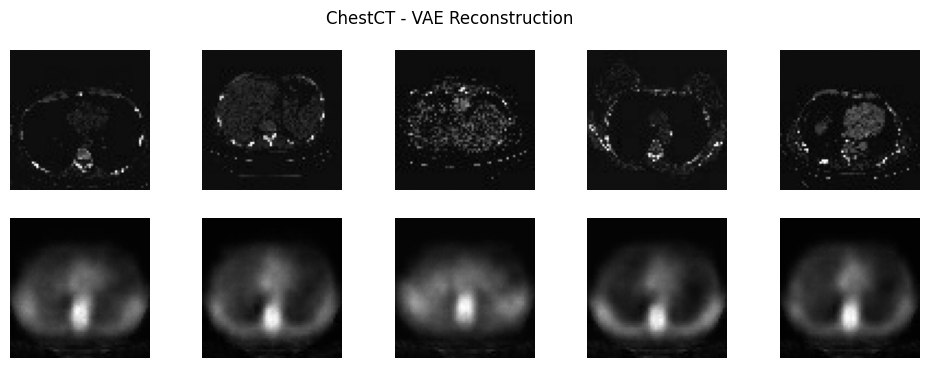

Training Region: Hand
Found 10000 files.
=============== AutoEncoder ===============
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - loss: 0.0494
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - loss: 0.0187
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - loss: 0.0127
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - loss: 0.0102
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - loss: 0.0092


<Figure size 640x480 with 0 Axes>

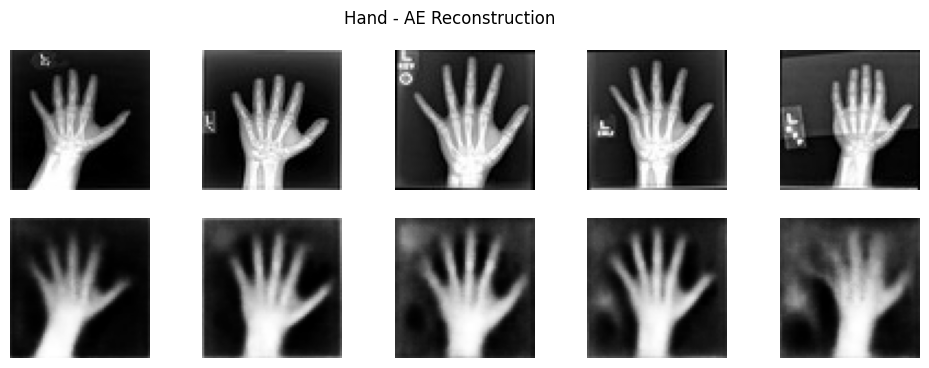

=============== Variational AutoEncoder ===============
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - kl_loss: 23.5775 - loss: 1701.5280 - recon_loss: 1677.9504
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - kl_loss: 27.2621 - loss: 1586.6427 - recon_loss: 1559.3806
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - kl_loss: 32.4893 - loss: 1388.4451 - recon_loss: 1355.9558
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - kl_loss: 29.6887 - loss: 1563.6121 - recon_loss: 1533.9233
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - kl_loss: 30.4454 - loss: 1592.5824 - recon_loss: 1562.1370


<Figure size 640x480 with 0 Axes>

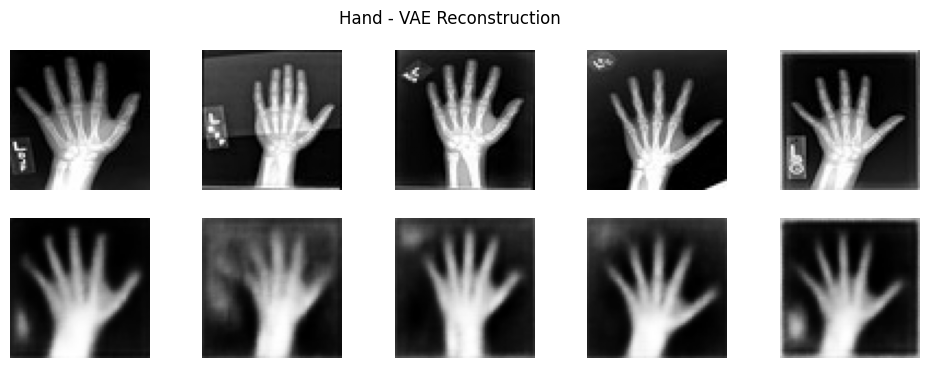

Training Region: HeadCT
Found 10000 files.
=============== AutoEncoder ===============
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - loss: 0.0482
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - loss: 0.0284
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - loss: 0.0175  
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 202s 1000ms/step - loss: 0.0127
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - loss: 0.0115


<Figure size 640x480 with 0 Axes>

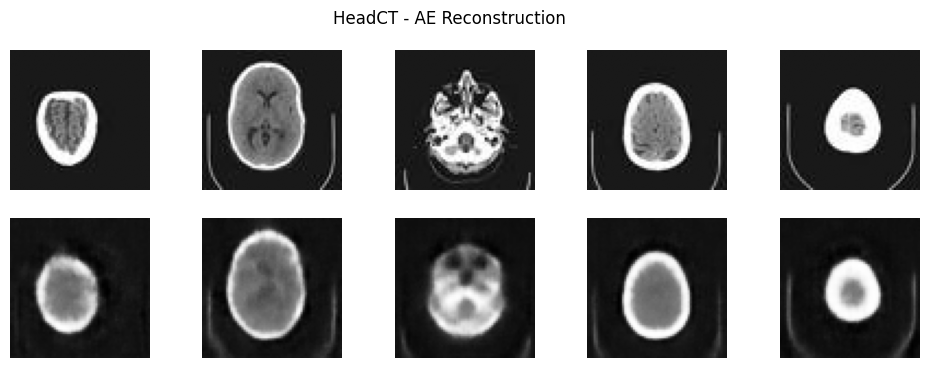

=============== Variational AutoEncoder ===============
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - kl_loss: 19.0245 - loss: 1846.6680 - recon_loss: 1827.6434
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - kl_loss: 19.2289 - loss: 1799.7922 - recon_loss: 1780.5634
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - kl_loss: 27.6778 - loss: 1667.4304 - recon_loss: 1639.7526
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - kl_loss: 27.3549 - loss: 1747.5433 - recon_loss: 1720.1885
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - kl_loss: 29.6634 - loss: 1722.4750 - recon_loss: 1692.8115


<Figure size 640x480 with 0 Axes>

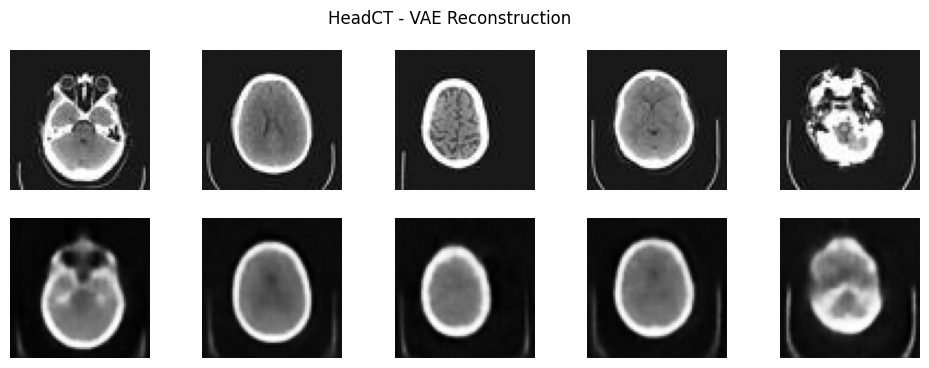

<Figure size 640x480 with 0 Axes>

In [44]:

for region in regions:

    print("="*60)
    print("Training Region:", region)

    ds = load_region_dataset(region)

    # ---------------------------
    # AUTOENCODER
    # ---------------------------
    if not results[region]["ae"]:
      print("="*15, "AutoEncoder", "="*15)

      ae = build_autoencoder()

      ae.fit(
          ds,
          epochs=EPOCHS,
          verbose=1
      )

      show_reconstruction(ae, ds, f"{region} - AE Reconstruction")
      plt.savefig(f"{region}-ae.png")
      # Save models
      ae.save(f"{region}_AE.h5")
      results[region]["ae"] = True
    # ---------------------------
    # VAE
    # ---------------------------
    if not results[region]["vae"]:
      print("="*15, "Variational AutoEncoder", "="*15)
      vae, encoder, decoder = build_vae()

      vae.fit(
          ds,
          epochs=EPOCHS,
          verbose=1
      )

      batch = next(iter(ds.take(1)))

      if isinstance(batch, tuple):
          sample = batch[0]
      else:
          sample = batch

      sample = sample[:5]

      z_mean, _, z = encoder(sample)
      recon = decoder(z)

      plt.figure(figsize=(12,4))

      for i in range(5):
          plt.subplot(2,5,i+1)
          plt.imshow(sample[i].numpy().squeeze(), cmap='gray')
          plt.axis('off')

          plt.subplot(2,5,i+6)
          plt.imshow(recon[i].numpy().squeeze(), cmap='gray')
          plt.axis('off')

      plt.suptitle(f"{region} - VAE Reconstruction")
      plt.show()
      plt.savefig(f"{region}-vae.png")

      decoder.save(f"{region}_VAE_decoder.h5")
      results[region]["vae"] = True

## Generation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


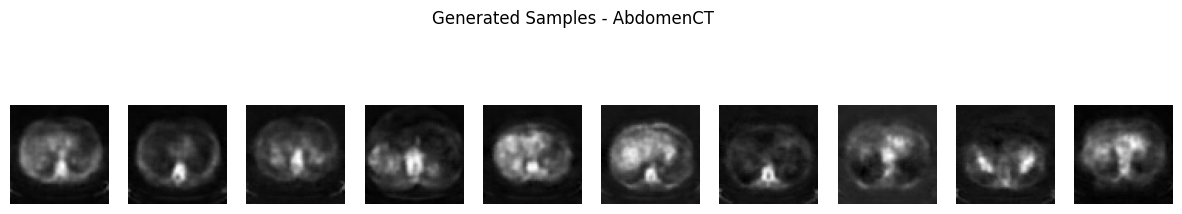

In [45]:
region = regions[0]

decoder = tf.keras.models.load_model(
    f"{region}_VAE_decoder.h5",
    compile=False
)

z = np.random.normal(size=(10, LATENT_DIM))
generated = decoder.predict(z)

plt.figure(figsize=(15,3))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle(f"Generated Samples - {region}")
plt.show()

In [46]:
print(results)


{'AbdomenCT': {'ae': True, 'vae': True}, 'BreastMRI': {'ae': True, 'vae': True}, 'CXR': {'ae': True, 'vae': True}, 'ChestCT': {'ae': True, 'vae': True}, 'Hand': {'ae': True, 'vae': True}, 'HeadCT': {'ae': True, 'vae': True}}


In [49]:
!zip models.zip *.h5

  adding: AbdomenCT_AE.h5 (deflated 11%)
  adding: AbdomenCT_VAE_decoder.h5 (deflated 9%)
  adding: BreastMRI_AE.h5 (deflated 8%)
  adding: BreastMRI_VAE_decoder.h5 (deflated 9%)
  adding: ChestCT_AE.h5 (deflated 12%)
  adding: ChestCT_VAE_decoder.h5 (deflated 8%)
  adding: CXR_AE.h5 (deflated 8%)
  adding: CXR_VAE_decoder.h5 (deflated 9%)
  adding: Hand_AE.h5 (deflated 8%)
  adding: Hand_VAE_decoder.h5 (deflated 9%)
  adding: HeadCT_AE.h5 (deflated 8%)
  adding: HeadCT_VAE_decoder.h5 (deflated 9%)
